In [1]:
# 🧪 LLM CODE AGENT BENCHMARK — CHEAP MODEL VERSION (COLAB SAFE)

# ============================================================
# SETUP
# ============================================================

import subprocess
import sys
import re
import json
import time
import multiprocessing
from io import StringIO
from contextlib import redirect_stdout, redirect_stderr
from dataclasses import dataclass, asdict
from collections import defaultdict
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4 pandas==2.1.4 --no-cache-dir

def install_if_needed():
    try:
        import numpy as np
        import pandas as pd
        from groq import Groq
        from datasets import load_dataset
        return
    except:
        print("📦 Installing dependencies...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "numpy==1.26.4",
                               "pandas",
                               "matplotlib",
                               "seaborn",
                               "groq",
                               "datasets",
                               "tqdm"])
        print("✅ Installed. Please RESTART runtime and run again.")
        raise SystemExit()

install_if_needed()

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from groq import Groq
from datasets import load_dataset
from google.colab import userdata, files

print("✅ Environment ready")

# ============================================================
# API SETUP
# ============================================================

api_key = userdata.get("GROQ_API_KEY")
if not api_key:
    raise ValueError("❌ Please set GROQ_API_KEY in Colab Secrets")

client = Groq(api_key=api_key)

# Validate API
client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "OK"}],
    max_tokens=3
)

print("✅ Groq API connected")

# ============================================================
# DATA STRUCTURE
# ============================================================

@dataclass
class EvalResult:
    task_id: str
    model: str
    attempt: int
    passed: bool
    error_type: str
    latency: float
    tokens: int

# ============================================================
# CODE PROCESSING
# ============================================================

def extract_code(text):
    if not text:
        return ""
    match = re.findall(r"```(?:python)?\n(.*?)```", text, re.DOTALL)
    if match:
        return match[0].strip()
    func_match = re.search(r"def\s+\w+\(.*", text, re.DOTALL)
    if func_match:
        return text[func_match.start():].strip()
    return text.strip()

def strip_to_function(code):
    lines = code.split("\n")
    result = []
    inside = False
    base_indent = 0

    for line in lines:
        stripped = line.strip()
        if stripped.startswith(("import ", "from ")):
            result.append(line)
            continue
        if stripped.startswith("def "):
            inside = True
            base_indent = len(line) - len(line.lstrip())
            result.append(line)
            continue
        if inside:
            indent = len(line) - len(line.lstrip())
            if indent > base_indent or stripped == "":
                result.append(line)
            else:
                break
    return "\n".join(result)

# ============================================================
# LLM GENERATION
# ============================================================

def generate_code(prompt, model):
    start = time.time()
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content":
                 "You are an expert Python programmer. Output ONLY the function implementation."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2,
            max_tokens=512   # 🔥 Reduced for cost efficiency
        )

        code = extract_code(response.choices[0].message.content)
        code = strip_to_function(code)

        if len(code.strip()) < 10:
            return "", time.time()-start, response.usage.total_tokens

        return code, time.time()-start, response.usage.total_tokens

    except Exception as e:
        print(f"⚠️ {model}: {e}")
        return "", time.time()-start, 0

# ============================================================
# SANDBOX (COLAB SAFE)
# ============================================================

def run_code(full_code, return_dict):
    try:
        namespace = {}
        with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
            exec(full_code, namespace)
        return_dict["passed"] = True
        return_dict["error"] = None
    except SyntaxError:
        return_dict["passed"] = False
        return_dict["error"] = "syntax_error"
    except AssertionError:
        return_dict["passed"] = False
        return_dict["error"] = "wrong_output"
    except Exception:
        return_dict["passed"] = False
        return_dict["error"] = "runtime_error"

def execute_code(code, test, entry_point, timeout=5):
    if not code:
        return False, "empty_code"

    full_code = f"""
{code}

candidate = {entry_point}

{test}

check(candidate)
"""

    manager = multiprocessing.Manager()
    return_dict = manager.dict()

    p = multiprocessing.Process(target=run_code, args=(full_code, return_dict))
    p.start()
    p.join(timeout)

    if p.is_alive():
        p.terminate()
        p.join()
        return False, "timeout"

    return return_dict.get("passed", False), return_dict.get("error", "runtime_error")

print("✅ Sandbox ready")

# ============================================================
# LOAD DATASET
# ============================================================

print("📥 Loading HumanEval...")
dataset = load_dataset("openai_humaneval", split="test")

problems = [{
    "task_id": item["task_id"],
    "prompt": item["prompt"],
    "test": item["test"],
    "entry_point": item["entry_point"]
} for item in dataset]

print(f"✅ Loaded {len(problems)} tasks")

# ============================================================
# CONFIG (CHEAP RUN)
# ============================================================

SAMPLE_SIZE = 10
K_ATTEMPTS = 1

if SAMPLE_SIZE:
    problems = problems[:SAMPLE_SIZE]

models = [
    ("allam-2-7b", "groq"),
    ("llama-3.1-8b-instant", "groq"),
    ("openai/gpt-oss-20b", "groq"),
    ("meta-llama/llama-4-scout-17b-16e-instruct", "groq"),
]

print(f"🚀 Running {len(problems)} problems × {len(models)} models")

# ============================================================
# BENCHMARK LOOP
# ============================================================

results = []
stats = {m[0]: {"passed": 0, "failed": 0} for m in models}
total = len(problems) * len(models) * K_ATTEMPTS

with tqdm(total=total) as pbar:
    for problem in problems:
        for model_name, _ in models:
            for attempt in range(K_ATTEMPTS):

                code, latency, tokens = generate_code(problem["prompt"], model_name)
                passed, error = execute_code(code, problem["test"], problem["entry_point"])

                if passed:
                    stats[model_name]["passed"] += 1
                else:
                    stats[model_name]["failed"] += 1

                results.append(EvalResult(
                    task_id=problem["task_id"],
                    model=model_name,
                    attempt=attempt,
                    passed=passed,
                    error_type=error,
                    latency=latency,
                    tokens=tokens
                ))

                pbar.update(1)

# ============================================================
# METRICS
# ============================================================

def calc_pass_at_k(results, model):
    model_results = [r for r in results if r.model == model]
    by_task = defaultdict(list)
    for r in model_results:
        by_task[r.task_id].append(r.passed)
    return sum(any(v) for v in by_task.values()) / len(by_task)

metrics = []
for model_name, _ in models:
    pass1 = calc_pass_at_k(results, model_name)
    latency = np.mean([r.latency for r in results if r.model == model_name])
    metrics.append({
        "Model": model_name,
        "pass@1": f"{pass1*100:.1f}%",
        "Latency": f"{latency:.2f}s"
    })

metrics_df = pd.DataFrame(metrics)

print("\n📊 RESULTS")
print(metrics_df)

# ============================================================
# EXPORT
# ============================================================

results_df = pd.DataFrame([asdict(r) for r in results])
results_df.to_csv("detailed_results.csv", index=False)
metrics_df.to_csv("metrics_summary.csv", index=False)

print("\n📥 Downloading files...")
files.download("detailed_results.csv")
files.download("metrics_summary.csv")

print("\n🎉 BENCHMARK COMPLETE")


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.1.4
Uninstalling pandas-2.1.4:
  Successfully uninstalled pandas-2.1.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 73.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requir

✅ Environment ready
✅ Groq API connected
✅ Sandbox ready
📥 Loading HumanEval...
✅ Loaded 164 tasks
🚀 Running 10 problems × 4 models


  0%|          | 0/40 [00:00<?, ?it/s]


📊 RESULTS
                                       Model  pass@1 Latency
0                                 allam-2-7b   10.0%   0.34s
1                       llama-3.1-8b-instant   50.0%   0.13s
2                         openai/gpt-oss-20b   10.0%   0.42s
3  meta-llama/llama-4-scout-17b-16e-instruct  100.0%   0.48s

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 BENCHMARK COMPLETE



📊 FULL STATISTICAL SUMMARY

                                       model  total_tasks  pass_at_1  \
2  meta-llama/llama-4-scout-17b-16e-instruct           10      100.0   
1                       llama-3.1-8b-instant           10       50.0   
0                                 allam-2-7b           10       10.0   
3                         openai/gpt-oss-20b           10       10.0   

   avg_latency  median_latency  avg_tokens  total_tokens  tokens_per_success  
2     0.480205        0.438466       280.5          2805          280.499972  
1     0.130315        0.118425       214.7          2147          429.399914  
0     0.341394        0.326574       305.1          3051         3050.996949  
3     0.417370        0.395024       490.0          4900         4899.995100  


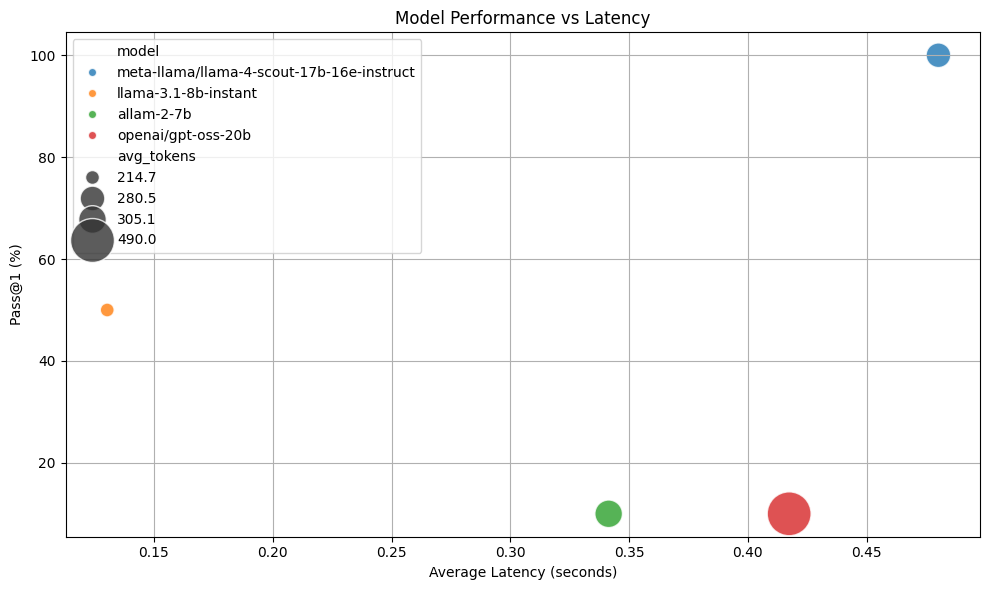


✅ Saved:
 - model_summary.csv
 - performance_vs_latency.png


In [3]:
# ============================================================
# HUMAN EVAL ANALYSIS PIPELINE
# ============================================================

!pip install pandas matplotlib seaborn --quiet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. LOAD RESULTS
# -----------------------------
df = pd.read_csv("detailed_results.csv")  # <-- Make sure your CSV is named this

# Convert boolean
df["passed"] = df["passed"].astype(str).str.upper() == "TRUE"

# -----------------------------
# 2. COMPUTE SUMMARY STATS
# -----------------------------
summary = (
    df.groupby("model")
      .agg(
          total_tasks=("task_id", "count"),
          pass_at_1=("passed", "mean"),
          avg_latency=("latency", "mean"),
          median_latency=("latency", "median"),
          avg_tokens=("tokens", "mean"),
          total_tokens=("tokens", "sum")
      )
      .reset_index()
)

summary["pass_at_1"] = summary["pass_at_1"] * 100

# Efficiency metric
summary["tokens_per_success"] = (
    summary["total_tokens"] /
    (df.groupby("model")["passed"].sum().values + 1e-6)
)

summary = summary.sort_values("pass_at_1", ascending=False)

print("\n📊 FULL STATISTICAL SUMMARY\n")
print(summary)

# Save summary
summary.to_csv("model_summary.csv", index=False)

# -----------------------------
# 3. PERFORMANCE VS LATENCY PLOT
# -----------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=summary,
    x="avg_latency",
    y="pass_at_1",
    size="avg_tokens",
    hue="model",
    sizes=(100, 1000),
    alpha=0.8
)

plt.title("Model Performance vs Latency")
plt.xlabel("Average Latency (seconds)")
plt.ylabel("Pass@1 (%)")
plt.grid(True)
plt.tight_layout()

plt.savefig("performance_vs_latency.png")
plt.show()

print("\n✅ Saved:")
print(" - model_summary.csv")
print(" - performance_vs_latency.png")
